In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings 

warnings.filterwarnings('ignore')

In [2]:
plt.style.use('default')
sns.set_palette("coolwarm")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

In [3]:
## Loading data and combining into a single DataFrame for easy IO

features_df = pd.read_csv(
    "./data/features.csv",
    names=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    skiprows=1
)
targets_df = pd.read_csv(
    "./data/targets.csv", header=None, names=["species"], skiprows=1
)


iris_df = pd.concat([features_df, targets_df], axis=1)
print("Dataset shape:", iris_df.shape)
iris_df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("statistics summary:\n", iris_df.describe())

statistics summary:
        sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [5]:
# Check for missing values and data types
print("Data Types and Missing Values:")
iris_df.info()

print("\nMissing Values Count:")
iris_df.isnull().sum()


Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values Count:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

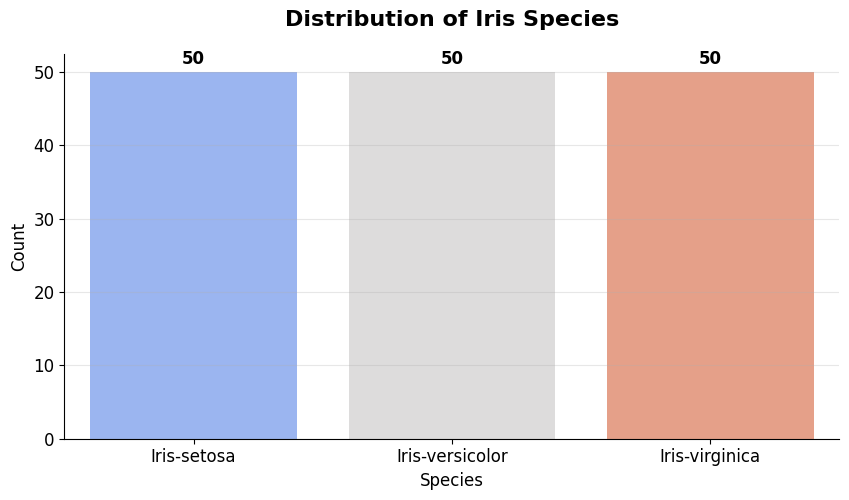

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
species_counts = iris_df["species"].value_counts()
g = sns.barplot(x=species_counts.index, y=species_counts.values, palette="coolwarm", ax=ax)

# adding labels to bars to make it easy to understand and read
for i, v in enumerate(species_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontweight="bold")
    
ax.set(xlabel="Species", ylabel="Count")
ax.set_title(label="Distribution of Iris Species", fontsize=16, fontweight="bold", pad=20)
sns.despine()

ax.grid(axis="y", alpha=0.3)

Now, let's check the features distribution to get a better understanding of the data

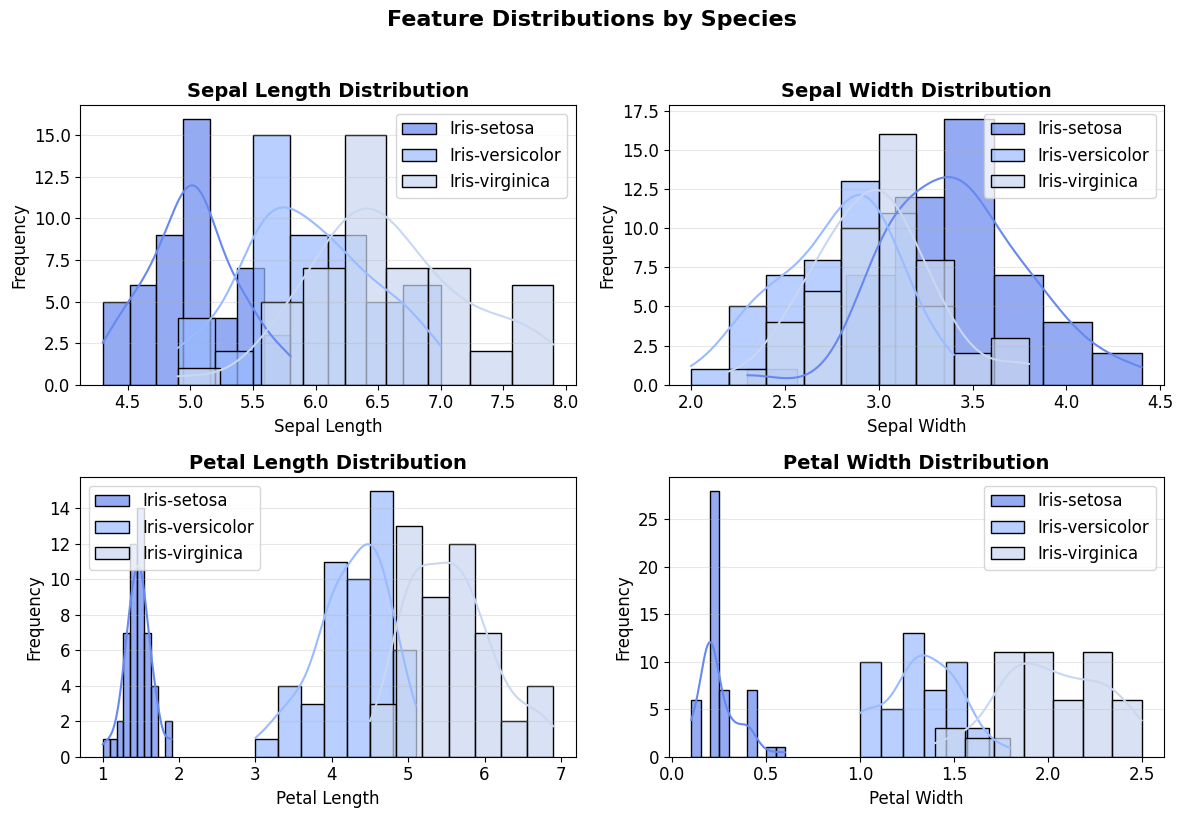

In [8]:
fig, axes = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
fig.suptitle("Feature Distributions by Species", fontsize=16, fontweight="bold", y=1.02)

features = iris_df.columns[:-1]
axes = axes.ravel()

for i, eachFeature in enumerate(features):
    for eachSpecies in iris_df["species"].unique():
        subset = iris_df[iris_df["species"] == eachSpecies]
        sns.histplot(
            subset[eachFeature], ax=axes[i], label=eachSpecies, alpha=0.7, kde=True
        )

    axes[i].set_title(
        f"{eachFeature.replace('_', ' ').title()} Distribution",
        fontsize=14,
        fontweight="bold",
    )
    axes[i].set_xlabel(eachFeature.replace("_", " ").title(), fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)
    axes[i].legend()
    axes[i].grid(axis="y", alpha=0.3)
    
plt.tight_layout()
plt.show()

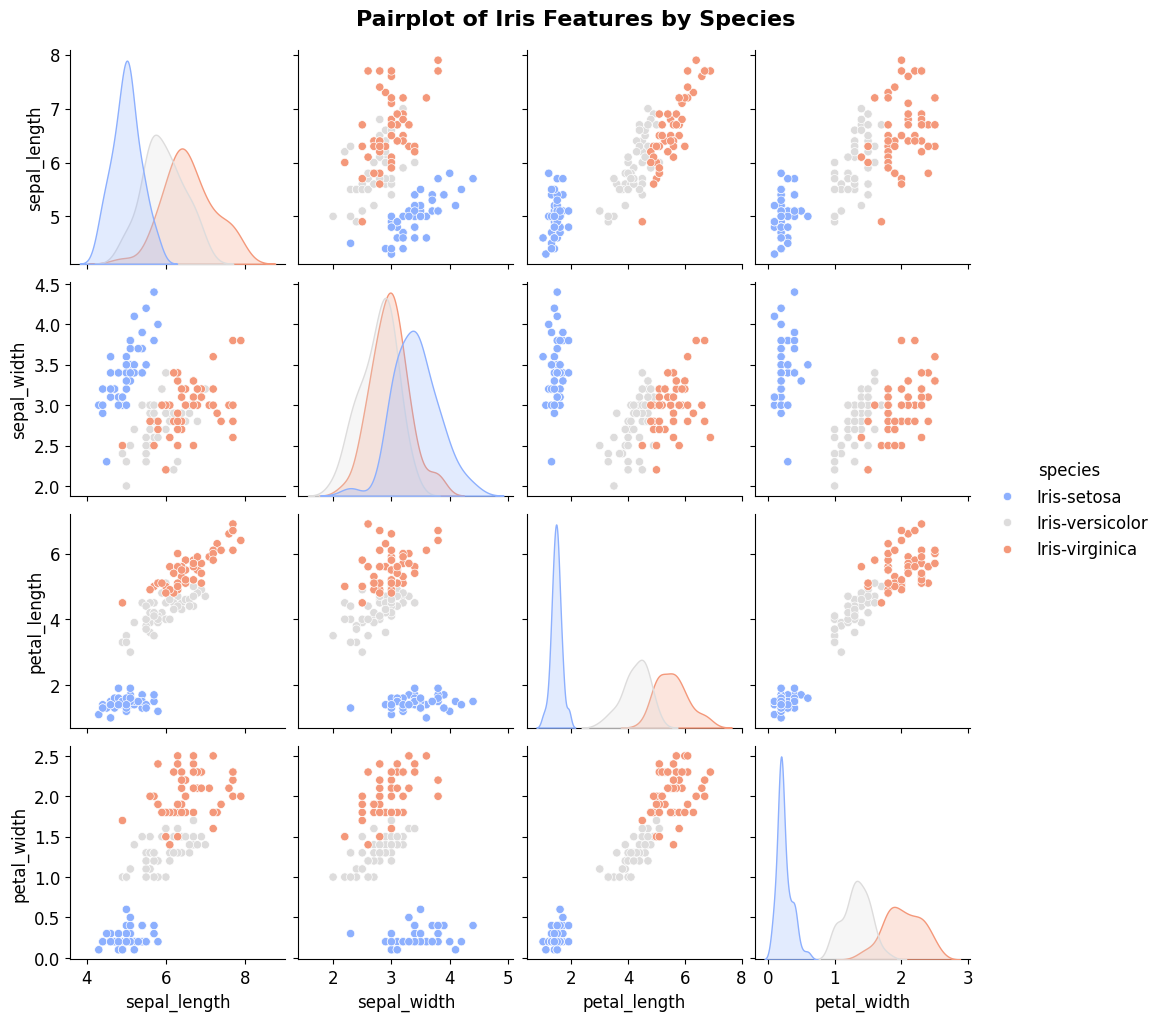

In [ ]:
## pairplot to visualize relationships between features
sns.pairplot(iris_df, hue="species", palette="coolwarm", diag_kind="kde")
plt.suptitle("Pairplot of Iris Features by Species", fontsize=16, fontweight="bold", y=1.02)
plt.show()

## for all charts just past them in chatGPT to interpret them.

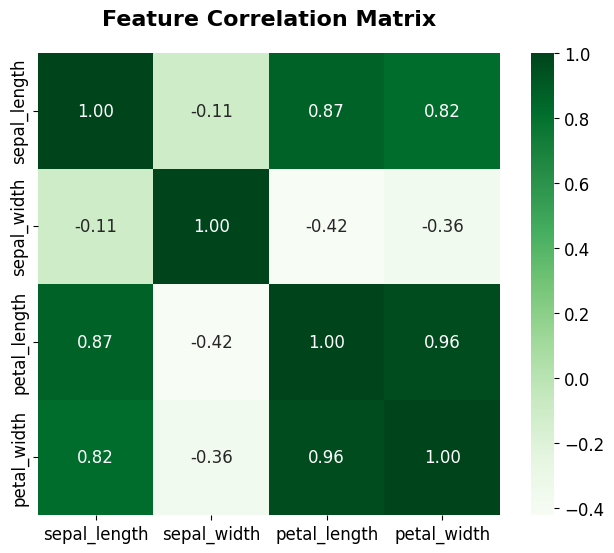

In [20]:
## Correlation of features using heatmap but showing only one side of the matrix
corr_matrix = iris_df.iloc[:, :-1].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Greens", fmt=".2f", square=True)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.show()

In [21]:
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1]  # Exclude self-correlation
print("High Correlation Pairs:\n", high_corr[high_corr.abs() > 0.7])

High Correlation Pairs:
 petal_length  petal_width     0.962757
petal_width   petal_length    0.962757
sepal_length  petal_length    0.871754
petal_length  sepal_length    0.871754
sepal_length  petal_width     0.817954
petal_width   sepal_length    0.817954
dtype: float64


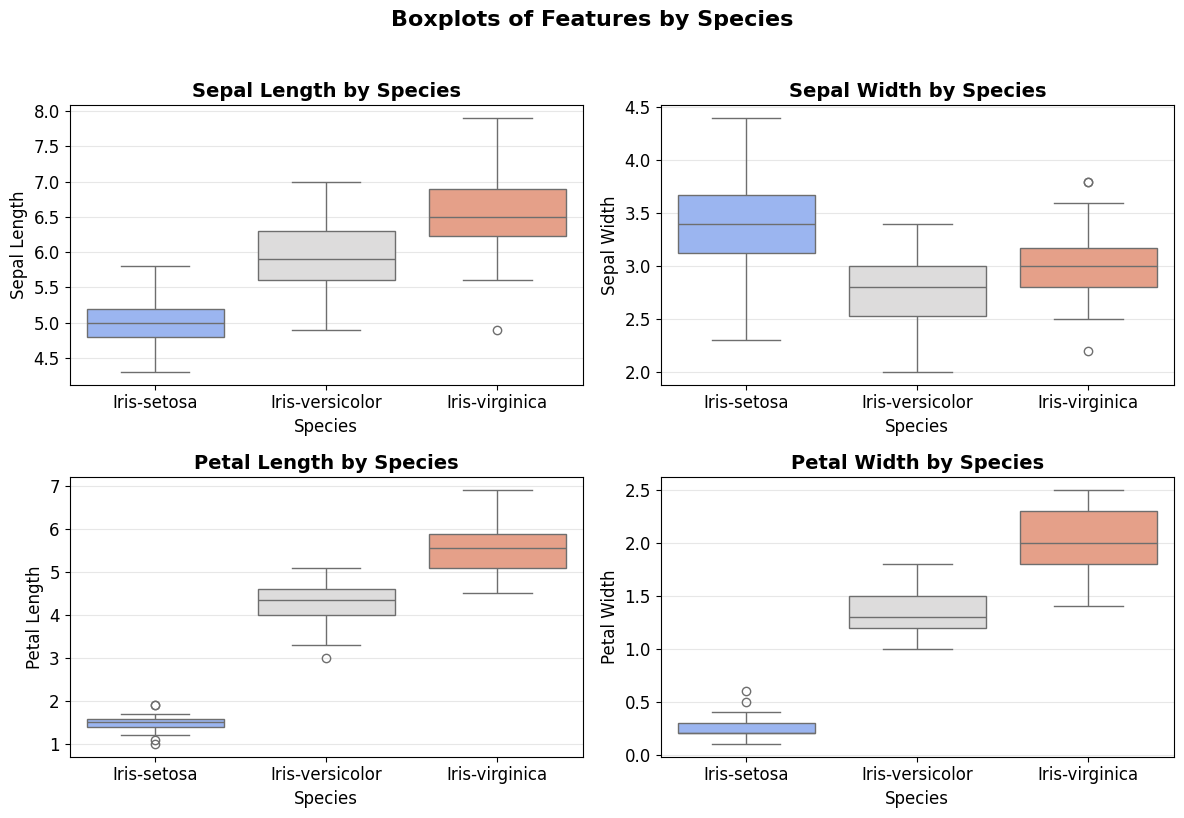

In [23]:
## Outlier detection using boxplots

fig, axes = plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
fig.suptitle("Boxplots of Features by Species", fontsize=16, fontweight="bold", y=1.02)
features = iris_df.columns[:-1]
axes = axes.ravel()
for i, eachFeature in enumerate(features):
    sns.boxplot(
        x="species",
        y=eachFeature,
        data=iris_df,
        ax=axes[i],
        palette="coolwarm"
    )
    axes[i].set_title(
        f"{eachFeature.replace('_', ' ').title()} by Species",
        fontsize=14,
        fontweight="bold",
    )
    axes[i].set_xlabel("Species", fontsize=12)
    axes[i].set_ylabel(eachFeature.replace("_", " ").title(), fontsize=12)
    axes[i].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

